In [35]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List,Literal
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel,Field
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


In [36]:
load_dotenv()

True

In [37]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [38]:
docs=(
    PyPDFLoader("./Documents/Company_Policies.pdf").load()+
    PyPDFLoader("./Documents/Company_Profile.pdf").load()+
    PyPDFLoader("./Documents/Product_and_pricing.pdf").load()
)

In [39]:
chunks=RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [40]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [41]:
vector_store=FAISS.from_documents(chunks,embeddings)

In [42]:
rtriever=vector_store.as_retriever(search_kwargs={"k":3})

In [43]:
class State(TypedDict):
    question:str

    retrieval_query:str
    rewrite_tries:int

    need_retrieval:bool

    docs:List[Document]
    relevant_docs:List[Document]

    context:str
    answer:str

    issup:Literal["fully_supported", "partially_supported", "no_support"]
    evidence:List[str]
    
    retries:int

    isuse:Literal["useful","not_useful"]
    use_reason:str

In [44]:
class RetrieveDecision(BaseModel):
    should_retrieve:bool=Field(
        description="True if exteral documentds are needed to answer reliably,else false."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm=llm.with_structured_output(RetrieveDecision)

In [45]:
def decide(state:State):
    descision:RetrieveDecision=should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state['question'])
    )
    return {
        "need_retrieval":descision.should_retrieve
    }

In [46]:
def route_after_decide(state:State)->Literal["Generate","Retrieve"]:
    if state["need_retrieval"]:
        return "Retrieve"
    return "Generate"

In [47]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate(state:State):
    out=llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer":out.content
    }

In [48]:
def retrieve(state:State):
    return {
        "docs":rtriever.invoke(state["question"])
    }

In [49]:
class RelevenceDecision(BaseModel):
    is_relevant:bool=Field(
        description="True ONLY if the document contains info that can directly answer the question."
    )


is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

relevence_llm=llm.with_structured_output(RelevenceDecision)

def is_relevent(state:State):
    relevant_docs :List[Document]=[]

    for doc in state["docs"]:
        descision:RelevenceDecision=relevence_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if descision.is_relevant:
            relevant_docs.append(doc)

    return {
        "relevant_docs":relevant_docs 
    }

In [50]:
def route_after_relevence(state:State)->Literal["From Relevent Docs","No Relevent Docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "From Relevent Docs"
    return "No Relevent Docs"

In [51]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)

In [52]:
def generate_from_contex(state:State):
    context="\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {
            "answer":"No relevant document found.",
            "context": ""
        }
    
    out=llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {
        "answer":out.content,
        "context":context
    }

In [53]:
def no_answer_docs(state:State):
    return {
        "answer": "No relevant document found.",
        "context": ""
    }

In [54]:
class IsSUPDescision(BaseModel):
    issup:Literal["fully_supported", "partially_supported", "no_support"]
    evidence:List[str]=Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_llm=llm.with_structured_output(IsSUPDescision)

In [55]:
def is_sup(state:State):
    descision:IsSUPDescision=issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )
    return {
        "issup":descision.issup,
        "evidence":descision.evidence
    }

In [56]:
MAX_RERIES=10

def route_after_issup(state:State)->Literal["Accept","Revise"]:
    if state.get("issup")=="fully_supported":
        return "Accept"
    
    if state.get("retries",0)>=MAX_RERIES:
        return "Accept"
    
    return "Revise"

In [57]:
def accept_answer(state:State):
    return {}

In [58]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

In [59]:
def revise_answer(state:State):
    out=llm.invoke(
        revise_prompt.format_messages(
            question=state['question'],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )

    return {
        "answer":out.content,
        "retries":state.get("retries",0)+1
    }

In [60]:
class IsUSEDecision(BaseModel):
    isuse:Literal["useful","not_useful"]
    reason:str=Field(description="Short reason in 1 line")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm=llm.with_structured_output(IsUSEDecision)

In [61]:
def is_use(state:State):
    decision:IsUSEDecision=isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer","")
        )
    )
    return {
        "isuse":decision.isuse,
        "use_reason":decision.reason
    }

In [62]:
MAX_RERIES_TRIES=3


In [63]:
def route_after_isuse(state:State)->Literal["END","No Relevent Docs","Rewrite Question"]:
    if state.get("isuse")=="useful":
        return "END"
    if state.get("rewrite_tries",0)>=MAX_RERIES_TRIES:
        return "No Relevent Docs"
    return "Rewrite Question"

In [64]:
class ReWriteDecision(BaseModel):
    retrieval_query:str=Field(description="Rewritten query optimized for vector retrieval against internal company PDFs.")

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

rewrite_llm=llm.with_structured_output(RetrieveDecision)

In [65]:
def rewrite_question(state:State):
    decision:ReWriteDecision=rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query",""),
            answer=state.get("answer","")
        )
    )

    return{
        "retreval_query":decision.retrieval_query,
        "rewrite_tries":state.get("rewrite_tries",0)+1,
        "docs":[],
        "relevant_docs":[],
        "context":"",
    }

In [66]:
g=StateGraph(State)

g.add_node("Decide",decide)
g.add_node("Generate",generate)

g.add_node("Relevent",is_relevent)
g.add_node("Retrieve",retrieve)

g.add_node("From Relevent Docs",generate_from_contex)
g.add_node("No Relevent Docs",no_answer_docs)

g.add_node("Is Supportive",is_sup)

# g.add_node("Accept",accept_answer)
g.add_node("Revise",revise_answer)

g.add_node("Is use",is_use)

g.add_node("Rewrite Question",rewrite_question)

g.add_edge(START,"Decide")
g.add_conditional_edges(
    "Decide",
    route_after_decide,
    {
        "Retrieve":"Retrieve",
        "Generate":"Generate"
    }
)

g.add_edge("Generate",END)

g.add_edge("Retrieve","Relevent")

g.add_conditional_edges(
    "Relevent",
    route_after_relevence,
    {
        "From Relevent Docs":"From Relevent Docs",
        "No Relevent Docs":"No Relevent Docs"
    }
)
g.add_edge("From Relevent Docs","Is Supportive")

g.add_conditional_edges(
    "Is Supportive",
    route_after_issup,
    {
        "Accept":"Is use",
        "Revise":"Revise"
    }
)

g.add_edge("Revise","Is Supportive")
g.add_conditional_edges(
    "Is use",
    route_after_isuse,
    {
        "END":END,
        "Rewrite Question":"Rewrite Question",
        "No Relevent Docs":"No Relevent Docs"
    }
)

g.add_edge("Rewrite Question","Retrieve")

g.add_edge("No Relevent Docs",END)

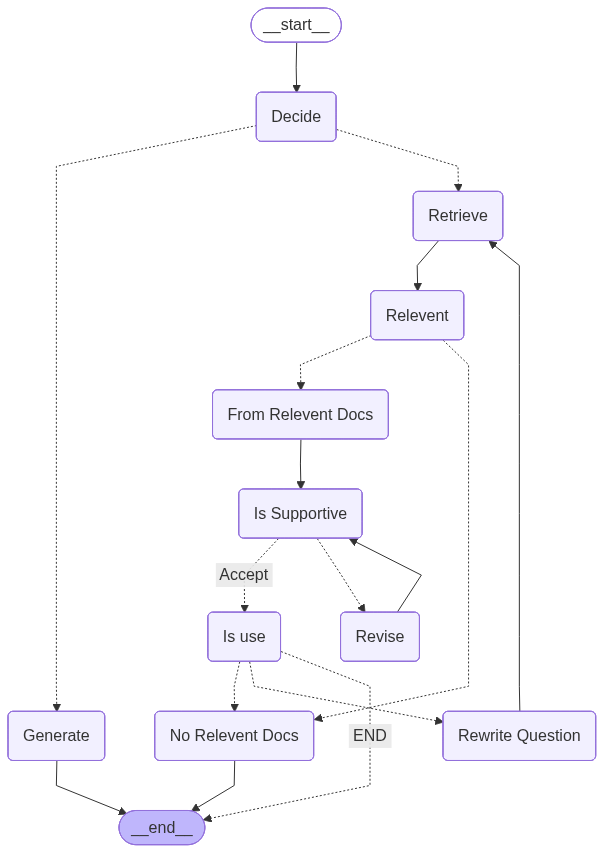

In [67]:
app=g.compile()
app

In [68]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI’s company culture.",
    "retrieval_query": "What is the refund policy of NexaAI",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 1

Retrieval:
  Total retrieved docs: 3
  Relevant docs: 1

Relevant docs (source/page):
  1. source=./Documents/Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Equal opportunity employer
   - Bi-annual performance reviews

Usefulness (IsUSE):
  isuse: useful
  reason: The answer directly lists aspects of NexaAI's workplace values and policies, which describes its company culture.

Final Answer:
- NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- Equal opportunity employer
- Bi-annual performance reviews
- Clear career progression framework
- Strict anti-harassment policy
- Employees are encouraged to maintain a healthy work-life balance.




In [69]:
result['need_retrieval']

True

In [70]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision
****************************************************************************************************
NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy wor

In [71]:
from pprint import pprint
pprint(result)

{'answer': '- NexaAI is committed to maintaining a fair, inclusive, and '
           'performance-driven workplace.\n'
           '- Equal opportunity employer\n'
           '- Bi-annual performance reviews\n'
           '- Clear career progression framework\n'
           '- Strict anti-harassment policy\n'
           '- Employees are encouraged to maintain a healthy work-life '
           'balance.',
 'context': 'NexaAI Solutions – Company Policies\n'
            'HR Policies\n'
            'NexaAI is committed to maintaining a fair, inclusive, and '
            'performance-driven workplace.\n'
            'All employment decisions are made without discrimination.\n'
            '\x7f\n'
            'Equal opportunity employer\n'
            '\x7f\n'
            'Bi-annual performance reviews\n'
            '\x7f\n'
            'Clear career progression framework\n'
            '\x7f\n'
            'Strict anti-harassment policy\n'
            'Leave Policy\n'
            'Employees 